# Football Playing Style Analysis

This notebook combines team-level attacking, defensive, movement, passing, and physical statistics for the 2026 World Cup.
The goal is to identify distinct playing-style clusters using feature selection, scaling, PCA, and K-Means clustering.

We document each decision so the analysis is easy to follow and reproduce.


## 1. Setup and data loading

Import required libraries and load the five CSV files.
Rank columns are dropped because they are derived ordinal values rather than raw performance metrics.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [3]:
attacking_data = pd.read_csv("worldcup_2026_team_attacking_stats.csv").drop("Rank", axis=1)
defensive_data = pd.read_csv("worldcup_2026_team_defensive_stats.csv").drop("Rank", axis=1)
movement_data = pd.read_csv("worldcup_2026_team_offers_receptions_stats.csv").drop("Rank", axis=1)
passing_data = pd.read_csv("worldcup_2026_team_passing_stats.csv").drop("Rank", axis=1)
physical_data = pd.read_csv("worldcup_2026_team_physical_stats.csv").drop("Rank", axis=1)


In [4]:
merged_data = (
    attacking_data
    .merge(defensive_data, on="Team")
    .merge(movement_data, on="Team")
    .merge(passing_data, on="Team")
    .merge(physical_data, on="Team")
)


## 2. Inspect the merged dataset

Verify the merged data shape, columns, and missing values before selecting features for playing-style analysis.


In [5]:
print("Merged data shape:", merged_data.shape)
print("Columns:", merged_data.columns.tolist())
display(merged_data.head())
print("Missing values by column:")
print(merged_data.isna().sum())


Merged data shape: (48, 43)
Columns: ['Team', 'Goals', 'Assists', 'Attempts at goal', 'Attempts on target', 'Attempts off target', 'Attempt at goal conversion rate', 'Attempts inside the penalty area', 'Attempts outside the penalty area', 'Headed attempts at goal', 'xG', 'xG efficiency', 'Corners', 'Possession control', 'Own goals', 'Goals conceded', 'Forced turnovers', 'Ball recovery time', 'Defensive pressures applied', 'Defensive pressures directly applied', 'Offers to receive', 'Offers in behind', 'Offers in between', 'Offers in front', 'Offers inside team shape', 'Offers outside team shape', 'Receptions in behind', 'Receptions between midfield and defensive line', 'Receptions under pressure', 'Passes', 'Passes Completed', 'Passing accuracy', 'Crosses', 'Crossing accuracy', 'Take-ons completed', 'Defensive line breaks attempted', 'Defensive line breaks accuracy', 'Switches of play attempted', 'Switches of play accuracy', 'Average Speed', 'High Speed Running', 'Sprints', 'Total Dist

,Team,Goals,Assists,Attempts at goal,Attempts on target,Attempts off target,Attempt at goal conversion rate,Attempts inside the penalty area,Attempts outside the penalty area,Headed attempts at goal,...,Crossing accuracy,Take-ons completed,Defensive line breaks attempted,Defensive line breaks accuracy,Switches of play attempted,Switches of play accuracy,Average Speed,High Speed Running,Sprints,Total Distance
0,England,20,14,118,52,40,17,88,30,27,...,27,85,207,66,48,81,5.88,9699,3537,918867.71
1,France,20,18,139,59,59,14,77,62,10,...,16,87,170,66,41,93,5.93,9253,3318,879396.52
2,Argentina,19,12,115,46,49,17,66,49,22,...,32,58,138,57,39,95,5.61,9631,3370,955124.09
3,Spain,14,10,140,54,59,10,79,61,22,...,20,74,206,66,53,96,6.04,10382,3645,947574.41
4,Belgium,14,10,112,35,43,13,74,38,16,...,28,68,138,51,30,77,6.24,8583,3002,739536.58


Missing values by column:
Team                                              0
Goals                                             0
Assists                                           0
Attempts at goal                                  0
Attempts on target                                0
Attempts off target                               0
Attempt at goal conversion rate                   0
Attempts inside the penalty area                  0
Attempts outside the penalty area                 0
Headed attempts at goal                           0
xG                                                0
xG efficiency                                     0
Corners                                           0
Possession control                                0
Own goals                                         0
Goals conceded                                    0
Forced turnovers                                  0
Ball recovery time                                0
Defensive pressures applied           

## 3. Select features representing playing style

Drop columns that describe outcomes, totals, or results rather than tactical style.
This keeps clustering focused on how teams play, not simply how many goals they scored or conceded.


In [6]:
excluded_columns = [
    "Goals",
    "Assists",
    "Own goals",
    "Goals conceded",
    "xG efficiency",
    "Attempt at goal conversion rate",
    "Team",
    "Attempts on target",
    "Attempts off target",
    "Headed attempts at goal"
]
team_playing_style_data = merged_data.drop(excluded_columns, axis=1)
playing_style_features = team_playing_style_data.columns.tolist()
print("Selected playing-style features:", playing_style_features)


Selected playing-style features: ['Attempts at goal', 'Attempts inside the penalty area', 'Attempts outside the penalty area', 'xG', 'Corners', 'Possession control', 'Forced turnovers', 'Ball recovery time', 'Defensive pressures applied', 'Defensive pressures directly applied', 'Offers to receive', 'Offers in behind', 'Offers in between', 'Offers in front', 'Offers inside team shape', 'Offers outside team shape', 'Receptions in behind', 'Receptions between midfield and defensive line', 'Receptions under pressure', 'Passes', 'Passes Completed', 'Passing accuracy', 'Crosses', 'Crossing accuracy', 'Take-ons completed', 'Defensive line breaks attempted', 'Defensive line breaks accuracy', 'Switches of play attempted', 'Switches of play accuracy', 'Average Speed', 'High Speed Running', 'Sprints', 'Total Distance']


## 4. Scale the selected features

StandardScaler brings all features onto the same scale so that large-magnitude metrics do not dominate the clustering.


In [7]:
scaler = StandardScaler()
scaled_playing_style_data = scaler.fit_transform(team_playing_style_data)


## 5. Reduce dimensionality with PCA

PCA reduces noise and makes it easier to visualize relationships between teams by projecting playing-style features into fewer components.


In [8]:
pca = PCA(n_components=min(12, scaled_playing_style_data.shape[1]))
pca_data = pca.fit_transform(scaled_playing_style_data)
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio for the first components:", explained_variance.round(3))
print("Cumulative explained variance for the selected components:", explained_variance.cumsum().round(3))


Explained variance ratio for the first components: [0.733 0.07  0.047 0.036 0.023 0.018 0.014 0.011 0.01  0.008 0.007 0.005]
Cumulative explained variance for the selected components: [0.733 0.804 0.85  0.886 0.909 0.927 0.941 0.952 0.961 0.97  0.977 0.982]


## 6. Choose the number of clusters with the elbow method

The elbow method shows how inertia changes as the number of clusters increases.
We use this to select a cluster count that balances explanation and compactness.


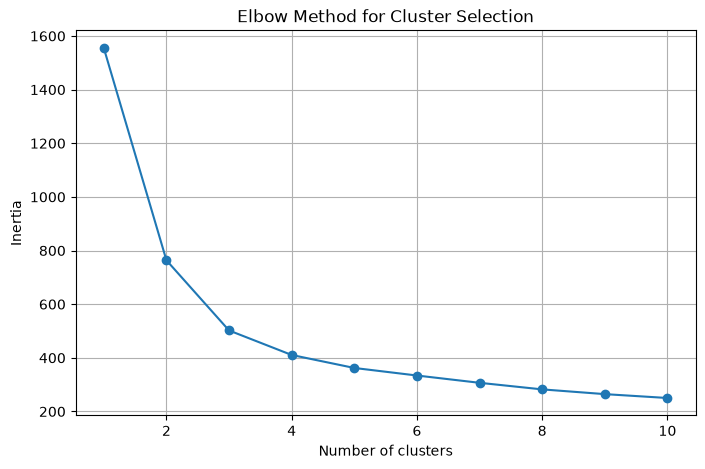

In [9]:
inertia = []
cluster_range = range(1, 11)
for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(pca_data)
    inertia.append(model.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Cluster Selection")
plt.grid(True)
plt.show()


## 7. Fit K-Means and assign cluster labels

Using the selected number of clusters, we group teams with similar playing-style feature profiles.
Cluster labels are added back to the merged dataset for further exploration.


In [10]:
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_data)
merged_data["Cluster"] = clusters
print("Cluster sizes:", merged_data["Cluster"].value_counts().sort_index())


Cluster sizes: Cluster
0    13
1     4
2     9
3     1
4     3
5     7
6     7
7     1
8     1
9     2
Name: count, dtype: int64


## 8. Visualize team clusters in PCA space

Plot the first two principal components to inspect how teams group by playing style.
Annotating each point makes it easier to connect clusters with actual team identities.


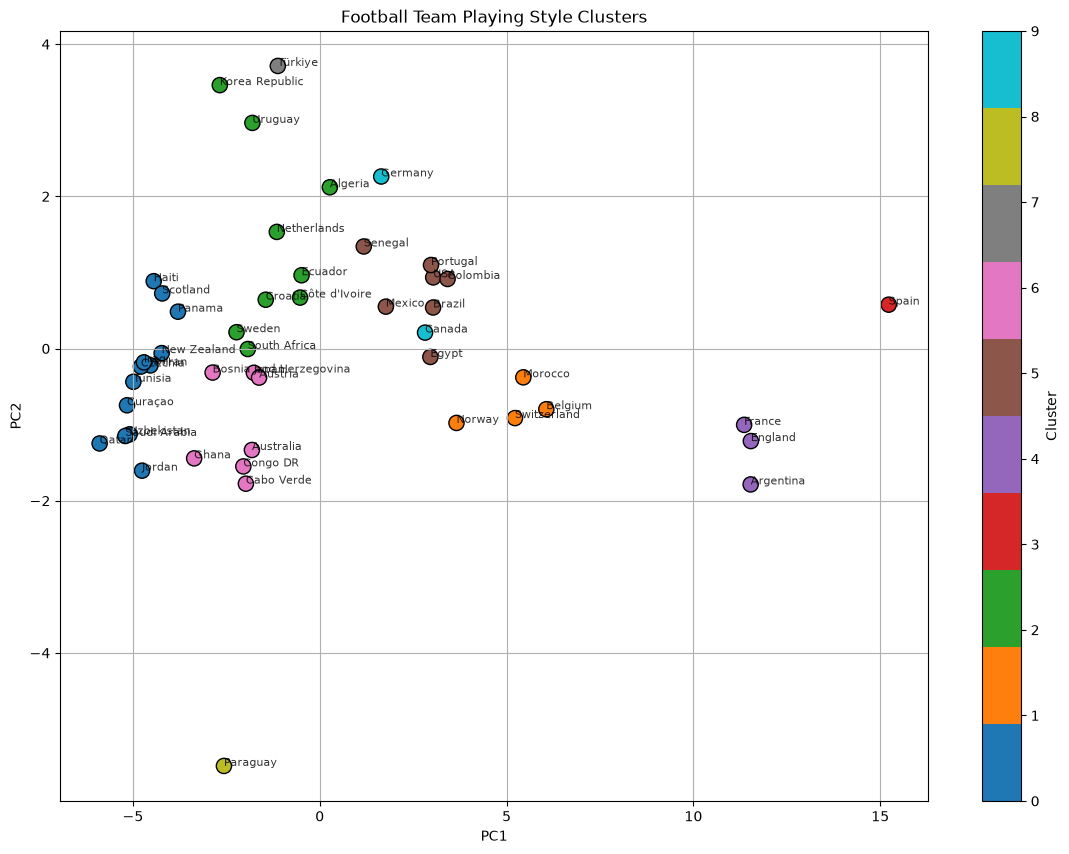

In [11]:
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=clusters,
    cmap="tab10",
    s=120,
    edgecolor="k"
)
for i, team in enumerate(merged_data["Team"]):
    plt.text(pca_data[i, 0], pca_data[i, 1], team, fontsize=8, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Football Team Playing Style Clusters")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")
plt.show()


## 9. Analyze cluster profiles

Compute the average playing-style metrics for each cluster to understand the tactical characteristics captured by the model.


In [12]:
cluster_profile = (
    merged_data.groupby("Cluster")[playing_style_features]
    .mean()
    .round(2)
)
display(cluster_profile)


,Attempts at goal,Attempts inside the penalty area,Attempts outside the penalty area,xG,Corners,Possession control,Forced turnovers,Ball recovery time,Defensive pressures applied,Defensive pressures directly applied,...,Crossing accuracy,Take-ons completed,Defensive line breaks attempted,Defensive line breaks accuracy,Switches of play attempted,Switches of play accuracy,Average Speed,High Speed Running,Sprints,Total Distance
Cluster,,,,,,,,,,,,,,,,,,,,,
0,26.00,15.31,10.69,2.12,9.08,36.46,122.38,56.71,885.23,142.46,...,26.38,21.08,49.62,38.23,14.15,79.00,6.03,3867.85,1316.77,336340.20
1,80.00,53.75,26.25,9.18,27.75,49.25,250.75,89.57,1504.50,260.00,...,24.25,54.75,123.75,48.00,26.50,78.25,6.05,8088.25,2841.25,724923.26
2,43.67,26.44,17.22,4.33,18.00,49.44,154.89,61.26,917.89,154.89,...,22.56,33.00,76.22,52.56,18.44,87.78,5.90,4504.89,1646.78,417249.13
3,140.00,79.00,61.00,17.48,54.00,58.00,399.00,90.89,1941.00,292.00,...,20.00,74.00,206.00,66.00,53.00,96.00,6.04,10382.00,3645.00,947574.41
4,124.00,77.00,47.00,15.75,44.00,51.33,318.33,126.63,1985.67,343.33,...,25.00,76.67,171.67,63.00,42.67,89.67,5.81,9527.67,3408.33,917796.11
5,70.43,45.14,25.29,7.43,23.71,49.86,193.57,77.14,1180.57,195.29,...,25.43,43.57,109.57,52.00,35.57,88.29,5.93,6252.86,2202.14,561641.63
6,36.43,18.14,18.29,2.92,13.14,37.71,164.29,77.69,1173.00,178.14,...,23.29,29.43,66.29,44.00,17.29,71.43,5.97,4945.57,1747.71,458136.71
7,70.00,37.00,33.00,5.50,22.00,58.00,121.00,29.94,490.00,123.00,...,14.00,37.00,75.00,60.00,30.00,73.00,6.10,3548.00,1289.00,350818.34
8,35.00,17.00,18.00,1.99,10.00,27.00,249.00,88.79,1689.00,331.00,...,17.00,30.00,71.00,25.00,18.00,83.00,5.90,6191.00,2141.00,592560.41


## 10. Summary and rationale

- We merged all relevant team statistics to create a unified dataset for playing-style analysis.
- We excluded outcome-focused and aggregate columns so that clustering emphasizes tactical and stylistic metrics.
- Standard scaling was applied to prevent features with large magnitudes from dominating the model.
- PCA reduced dimensionality and produced a visual representation of playing-style similarity.
- K-Means clustering grouped teams into style cohorts, and cluster profiling reveals the typical tactical signatures for each group.

This structure makes the notebook easier to follow and supports reproducible interpretation of football playing styles.
